# Библиотеки

In [4]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from pathlib import Path
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import MaxAbsScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from stop_words import get_stop_words
import matplotlib.pyplot as plt
from scipy.stats import entropy
import re
from nltk.corpus import stopwords
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from tqdm import tqdm

# Загрузка датасета

Из из наального датасета нам нужны поля subject, body, queue, priority, type

In [85]:
#from google.colab import drive
#drive.mount('/content/drive')
#%cd /content/drive/MyDrive/data/

In [6]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

df = dataset["train"].to_pandas()

print("Shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Shape: (61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [7]:
print(df.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')


In [8]:
def load_idx(path):
    with open(path) as f:
        return [int(x.strip()) for x in f.readlines()]

train_idx = load_idx("train_idx.txt")
val_idx   = load_idx("val_idx.txt")
test_idx  = load_idx("test_idx.txt")

print(len(train_idx), len(val_idx), len(test_idx))

49412 6176 6177


In [9]:
train_df = df.iloc[train_idx].copy()
val_df   = df.iloc[val_idx].copy()
test_df  = df.iloc[test_idx].copy()

In [10]:
def make_text(data):
    return (data["subject"].fillna("") + " " + data["body"].fillna("")).str.strip()

train_df["text"] = make_text(train_df)
val_df["text"]   = make_text(val_df)
test_df["text"]  = make_text(test_df)

# EDA

**Распределение по депаратментам**

In [11]:
train_df["queue"].value_counts().head(10)

,count
queue,
Technical Support,11354
Product Support,7139
Customer Service,5905
IT Support,4673
Billing and Payments,3853
Returns and Exchanges,1956
Service Outages and Maintenance,1534
Sales and Pre-Sales,1228
Human Resources,730


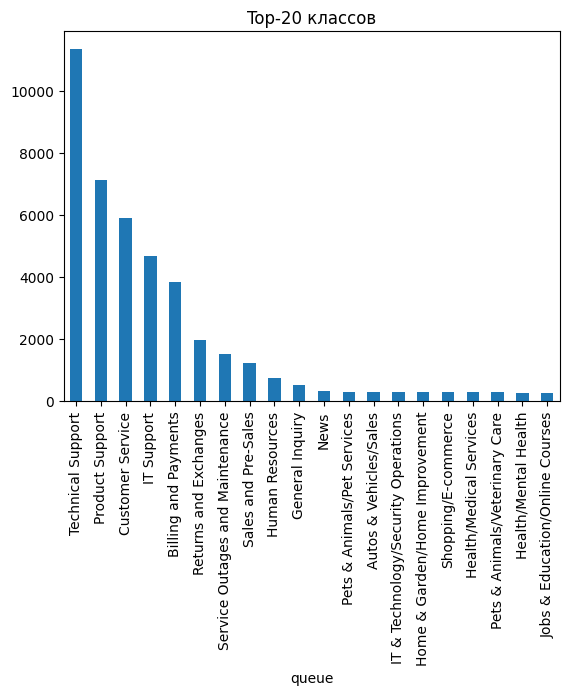

In [12]:
train_df["queue"].value_counts().head(20).plot(kind="bar")
plt.title("Top-20 классов")
plt.show()

По данным виден явный дисбаланс классов по департаментам. поэтому использование макро метрики оправдано.

**Распределение по прироритету и типу обращения**

In [13]:
print(train_df["priority"].value_counts())
print(train_df["type"].value_counts())

priority
medium      18629
high        17546
low         10280
critical     1516
very_low     1441
Name: count, dtype: int64
type
Incident    15632
Request     11165
Problem      8103
Change       4004
Name: count, dtype: int64


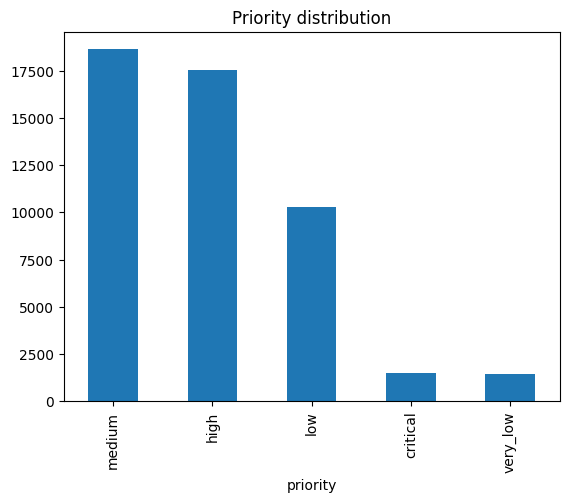

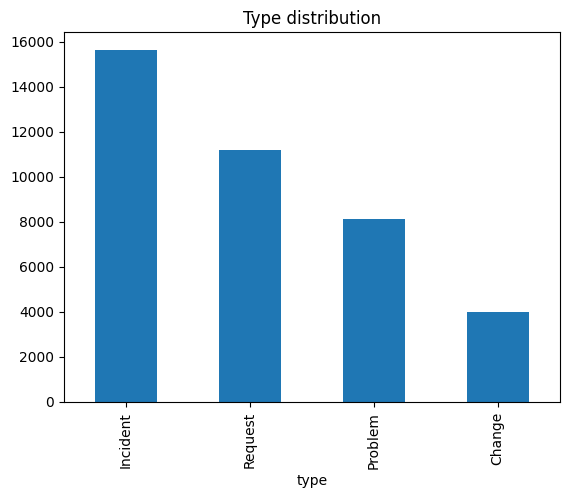

In [14]:
train_df["priority"].value_counts().plot(kind="bar")
plt.title("Priority distribution")
plt.show()

train_df["type"].value_counts().plot(kind="bar")
plt.title("Type distribution")
plt.show()

По этим категориям дисбаланс не такой выраженный, но тоже есть. Большинтство категорий имеют средний и сильный приорит.

По типу большинство инциденты или запросы.

**Характеристики текста по числу слов**

In [15]:
train_df["len"] = train_df["text"].str.len()
train_df["len"].describe()


,len
count,49412.000000
mean,463.666579
std,226.852141
min,4.000000
25%,278.000000
50%,459.000000
75%,633.000000
max,2284.000000


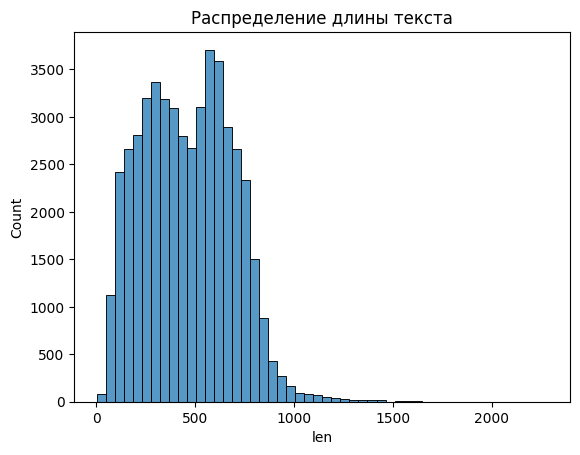

In [16]:
sns.histplot(train_df["len"], bins=50)
plt.title("Распределение длины текста")
plt.show()

Тексты имеют среднюю длину 464 символа с двумя выраженными пиками (около 300 и 600 знаков), что указывает на наличие двух разных типов контента в данных.
Для обучения стоит отсеять слишком короткие записи (минимум 4 символа) и увеличить max_features, так как 30 слов физически не смогут описать тексты такого объема.

**Распределение по группам**

In [17]:
train_df.groupby("queue")["len"].mean().sort_values().tail(20)

,len
queue,
Travel & Transportation/Land Travel,584.296296
Autos & Vehicles/Maintenance,586.755274
Real Estate,589.898396
Finance/Investments,590.796154
Business & Industrial/Manufacturing,592.962963
Hobbies & Leisure/Collectibles,596.634981
Jobs & Education/Recruitment,596.902128
Pets & Animals/Pet Services,597.006494
Food & Drink/Restaurants,600.357759


In [18]:
train_df.groupby("type")["len"].mean()

,len
type,
Change,476.444555
Incident,418.846277
Problem,415.356041
Request,443.835826


In [19]:
train_df.groupby("priority")["len"].mean()

,len
priority,
critical,590.849604
high,449.111478
low,466.483463
medium,457.359493
very_low,568.532269


Самые длинные и подробные тексты (560–590 симв.) характерны для  критических заявок, где важна каждая деталь, и очень низких по приоритету, которые часто содержат развернутый фидбек или идеи.
Техническая рутина (IT, HR, инциденты) описывается кратко и по делу, в то время как специфические темы вроде медицины или шопинга требуют от пользователей большего количества пояснений.

**Распределение по train/test/val**

In [20]:
train_dist = train_df["queue"].value_counts(normalize=True)
val_dist   = val_df["queue"].value_counts(normalize=True)
test_dist  = test_df["queue"].value_counts(normalize=True)

dist_df = pd.concat([train_dist, val_dist, test_dist], axis=1)
dist_df.columns = ["train", "val", "test"]

dist_df.fillna(0).head()

,train,val,test
queue,,,
Technical Support,0.229782,0.228951,0.229561
Product Support,0.144479,0.143135,0.151692
Customer Service,0.119505,0.121276,0.124008
IT Support,0.094572,0.086949,0.083374
Billing and Payments,0.077977,0.079177,0.086126


По трейну, тесту и валидации нет значимых различий и смещений

**Распределений по английскому/немецкому языку**

In [21]:
german_stop = get_stop_words('german')
english_stop = get_stop_words('english')

combined_stop_words = list(set(german_stop + english_stop))

vec = CountVectorizer(max_features=30, stop_words=combined_stop_words)
X = vec.fit_transform(train_df["text"])

word_counts = np.asarray(X.sum(axis=0)).flatten()
words = vec.get_feature_names_out()

freq_df = pd.DataFrame({"word": words, "count": word_counts})
freq_df.sort_values("count", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ain', 'daren', 'hadn', 'herse', 'himse', 'itse', 'mayn', 'mightn', 'mon', 'mustn', 'myse', 'needn', 'oughtn', 'shan', 'vis'] not in stop_words.
  warnings.warn(


,word,count
25,support,24430
5,data,24082
12,issue,14800
26,team,12970
24,software,12913
10,integration,10852
28,unterstützung,10261
1,assistance,10205
3,customer,8971
23,security,8820


Датасет Tobi-Bueck/customer-support-tickets содержит обращения в техподдержку, в основном посвященные техническим проблемам, интеграциям и безопасности в IT, медицине и финансах. Текст требует обработки, включая объединение стоп-слов и лемматизацию для корректного анализа терминологии на английском и немецком языках.


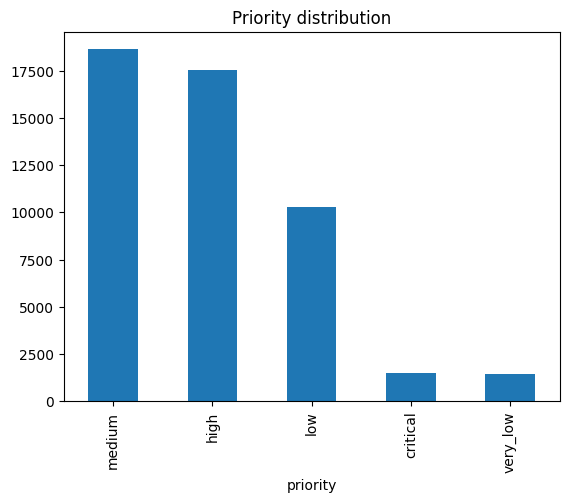

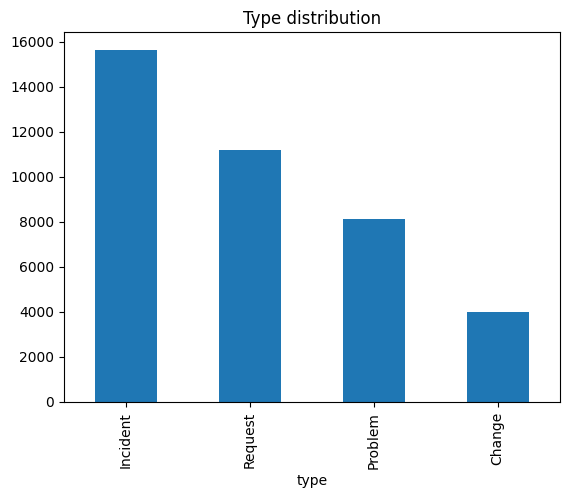

In [22]:
train_df["priority"].value_counts().plot(kind="bar")
plt.title("Priority distribution")
plt.show()

train_df["type"].value_counts().plot(kind="bar")
plt.title("Type distribution")
plt.show()

В датасете присутстыует 2 языка, при этом их доли примерно равны

In [23]:
train_df.groupby('language')['queue'].count()

,queue
language,
de,26799
en,22613


In [24]:
pd.crosstab(train_df["queue"], train_df["language"]).head(20)

language,de,en
queue,,
Arts & Entertainment/Movies,207,0
Arts & Entertainment/Music,243,0
Autos & Vehicles/Maintenance,237,0
Autos & Vehicles/Sales,287,0
Beauty & Fitness/Cosmetics,250,0
Beauty & Fitness/Fitness Training,240,0
Billing and Payments,1550,2303
Books & Literature/Fiction,232,0
Books & Literature/Non-Fiction,252,0


In [25]:
lang_queue = pd.crosstab(train_df["queue"], train_df["language"], normalize="index")
lang_queue[lang_queue['en'] > 0.5]

language,de,en
queue,,
Billing and Payments,0.402284,0.597716
Customer Service,0.426249,0.573751
General Inquiry,0.426692,0.573308
Human Resources,0.408219,0.591781
IT Support,0.419645,0.580355
Product Support,0.410562,0.589438
Returns and Exchanges,0.425869,0.574131
Sales and Pre-Sales,0.437296,0.562704
Service Outages and Maintenance,0.425684,0.574316


Итого у нас достаточно много категорий исключительно с немецким языком, при этом групп эксклюзивно с английским языком нет.

# Бейслайн (TF-IDF + Logreg) без пердобработки

In [26]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    #ngram_range=(3,5),
    min_df=3,
    max_df=0.9,
    max_features=50000
)

X_train = tfidf.fit_transform(train_df["text"])
X_val   = tfidf.transform(val_df["text"])
X_test  = tfidf.transform(test_df["text"])

In [27]:
clf = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

clf.fit(X_train, train_df["queue"])

LogisticRegression(max_iter=500, n_jobs=-1, random_state=42, solver='saga')

In [28]:
y_pred = clf.predict(X_test)

macro_f1 = f1_score(test_df["queue"], y_pred, average="macro")
acc = accuracy_score(test_df["queue"], y_pred)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.7325
Accuracy (queue): 0.5686


In [29]:
val_pred = clf.predict(X_val)

print("VAL Macro-F1:", f1_score(val_df["queue"], val_pred, average="macro"))
print("VAL Accuracy:", accuracy_score(val_df["queue"], val_pred))

VAL Macro-F1: 0.7448646337930249
VAL Accuracy: 0.572538860103627


# Бейслайн (TF-IDF + Logreg) со стоп словами

In [30]:
nltk.download("stopwords")

en_stop = set(stopwords.words("english"))
de_stop = set(stopwords.words("german"))

stop_words = en_stop.union(de_stop)

URL_RE = re.compile(r"http\S+|www\.\S+")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text)
    return text.strip()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [31]:
train_df["text_clean"] = train_df["text"].map(clean_text)
val_df["text_clean"]   = val_df["text"].map(clean_text)
test_df["text_clean"]  = test_df["text"].map(clean_text)

In [32]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    max_features=50000,
    stop_words=list(stop_words)
)

X_train = tfidf.fit_transform(train_df["text_clean"])
X_val   = tfidf.transform(val_df["text_clean"])
X_test  = tfidf.transform(test_df["text_clean"])

In [33]:
clf_2 = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

clf_2.fit(X_train, train_df["queue"])

LogisticRegression(max_iter=500, n_jobs=-1, random_state=42, solver='saga')

In [34]:
y_pred_2 = clf_2.predict(X_test)

macro_f1 = f1_score(test_df["queue"], y_pred_2, average="macro")
acc = accuracy_score(test_df["queue"], y_pred_2)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.7673
Accuracy (queue): 0.5826


# Transformer fine-tuning на multitask

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [36]:
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

train_df["queue_id"] = le_queue.fit_transform(train_df["queue"])
val_df["queue_id"]   = le_queue.transform(val_df["queue"])
test_df["queue_id"]  = le_queue.transform(test_df["queue"])

train_df["priority_id"] = le_priority.fit_transform(train_df["priority"])
val_df["priority_id"]   = le_priority.transform(val_df["priority"])
test_df["priority_id"]  = le_priority.transform(test_df["priority"])

train_df["type_id"] = le_type.fit_transform(train_df["type"])
val_df["type_id"]   = le_type.transform(val_df["type"])
test_df["type_id"]  = le_type.transform(test_df["type"])

In [37]:
MODEL_NAME = "xlm-roberta-base"

In [38]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size

        self.dropout = nn.Dropout(0.3)
        self.queue_head = nn.Linear(hidden, n_queue)
        self.priority_head = nn.Linear(hidden, n_priority)
        self.type_head = nn.Linear(hidden, n_type)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0]
        cls = self.dropout(cls)

        return (
            self.queue_head(cls),
            self.priority_head(cls),
            self.type_head(cls)
        )

In [39]:
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["text"].astype(str).values
        self.queue = df["queue_id"].values
        self.priority = df["priority_id"].values
        self.type = df["type_id"].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["queue"] = torch.tensor(self.queue[idx])
        item["priority"] = torch.tensor(self.priority[idx])
        item["type"] = torch.tensor(self.type[idx])

        return item

In [40]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TicketDataset(train_df, tokenizer)
val_ds   = TicketDataset(val_df, tokenizer)
test_ds  = TicketDataset(test_df, tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [41]:
model = MultiTaskModel(
    MODEL_NAME,
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_)
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader)

    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        q_logits, p_logits, t_logits = model(
            batch["input_ids"],
            batch["attention_mask"]
        )

        loss_q = criterion(q_logits, batch["queue"])
        loss_p = criterion(p_logits, batch["priority"])
        loss_t = criterion(t_logits, batch["type"])

        loss = 0.7 * loss_q + 0.15 * loss_p + 0.15 * loss_t

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss:", total_loss / len(train_loader))

Epoch 1: 100%|██████████| 3089/3089 [22:39<00:00,  2.27it/s, loss=1.31]


Epoch 1 Loss: 1.5811148324843247


Epoch 2: 100%|██████████| 3089/3089 [22:44<00:00,  2.26it/s, loss=1.08]


Epoch 2 Loss: 1.1440658657131708


Epoch 3: 100%|██████████| 3089/3089 [22:44<00:00,  2.26it/s, loss=0.82]

Epoch 3 Loss: 1.0125018961512953


In [43]:
def evaluate(model, loader):
    model.eval()

    q_true, q_pred = [], []
    p_true, p_pred = [], []
    t_true, t_pred = [], []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            q_logits, p_logits, t_logits = model(
                batch["input_ids"],
                batch["attention_mask"]
            )

            q_pred.extend(q_logits.argmax(1).cpu().numpy())
            p_pred.extend(p_logits.argmax(1).cpu().numpy())
            t_pred.extend(t_logits.argmax(1).cpu().numpy())

            q_true.extend(batch["queue"].cpu().numpy())
            p_true.extend(batch["priority"].cpu().numpy())
            t_true.extend(batch["type"].cpu().numpy())

    return (
        np.array(q_true), np.array(q_pred),
        np.array(p_true), np.array(p_pred),
        np.array(t_true), np.array(t_pred)
    )

In [44]:
y_q_true, y_q_pred, y_p_true, y_p_pred, y_t_true, y_t_pred = evaluate(model, test_loader)

macro_f1_queue = f1_score(y_q_true, y_q_pred, average="macro")
acc_queue = accuracy_score(y_q_true, y_q_pred)
acc_priority = accuracy_score(y_p_true, y_p_pred)
acc_type = accuracy_score(y_t_true, y_t_pred)

score = (
    0.70 * macro_f1_queue +
    0.15 * acc_priority +
    0.15 * acc_type
)

print("Macro-F1 (queue):", round(macro_f1_queue, 4))
print("Accuracy (queue):", round(acc_queue, 4))
print("Accuracy (priority):", round(acc_priority, 4))
print("Accuracy (type):", round(acc_type, 4))
print("FINAL SCORE:", round(score, 4))

Macro-F1 (queue): 0.843
Accuracy (queue): 0.5681
Accuracy (priority): 0.5564
Accuracy (type): 0.8295
FINAL SCORE: 0.798
